# **Preparar los datos**

Antes de empezar con la red neuronal como tal, importaremos todas las librerías necesarias para su correcto funcionamiento.

In [1]:
# %tensorflow_version 2.x

import tensorflow as tf
from tensorflow import keras

import numpy as np
import matplotlib.pyplot as plt

print(tf.__version__)

2026-01-27 16:33:36.053094: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-27 16:33:36.078599: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-27 16:33:37.061791: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-27 16:33:39.433822: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computat

2.20.0


A partir de este punto ya podemos cargar los datos, estos datos consistirán en una base de datos sobre imágenes de ropa.

In [2]:
fashion_mnist = keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Lo que devuelve el códgio anterior es las matrices correspondientes a los datos de entrenamiento y prueba, cada clase se corresponde a un tipo de ropa diferente. Cómo los nombres de las clases no se incluyen en el conjunto de imágenes, se creará un array con dichos nombre para usarlo más adelante.

In [3]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

Vamos a cambiar los valores de entrada a *float32* y luego a escalar en el rango [0-1].

In [4]:
train_images = train_images.astype('float32') / 255
test_images = test_images.astype('float32') / 255

Ahora comprobamos que los datos tengan el formato que nosotros queremos.

In [5]:
print("train_images.shape: ", train_images.shape)
print("len(train_labels): ", len(train_labels))
print("test_images.shape: ", test_images.shape)
print("len(test_labels): ", len(test_labels))

train_images.shape:  (60000, 28, 28)
len(train_labels):  60000
test_images.shape:  (10000, 28, 28)
len(test_labels):  10000


Lo mismo con las muestras y las etiquetas

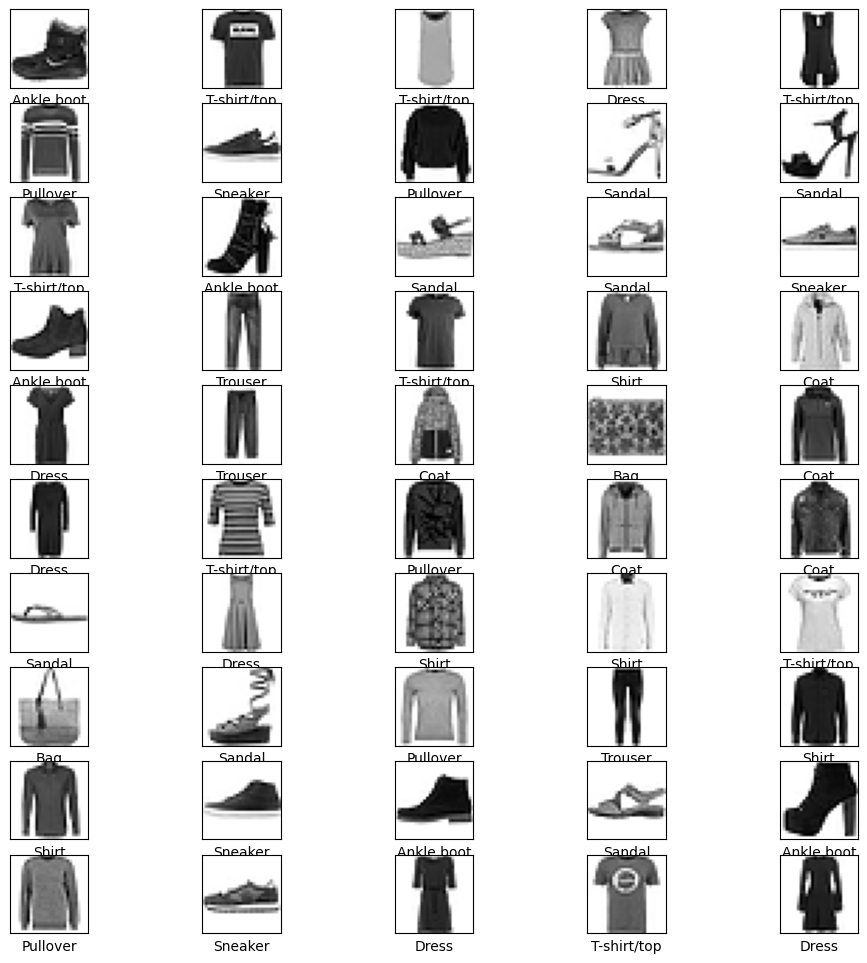

In [6]:
train_labels

plt.figure(figsize=(12, 12))
for i in range (50):
  plt.subplot(10, 5, i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(train_images[i], cmap=plt.cm.binary)
  plt.xlabel(class_names[train_labels[i]])
plt.show()

# **Definir el modelo**

Para definir el modelo, primero reconvertimos las muestras de entrada de 28 x 28 a un array de 784 números (concatenando fila a fila).

In [7]:
model = keras.Sequential()

model.add(keras.layers.Flatten(input_shape=(28, 28)))
model.add(keras.layers.Dense(10, activation='sigmoid'))
model.add(keras.layers.Dense(10, activation='softmax'))

/home/franco/Redes-Neuronales-en-Keras/.venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2026-01-27 16:34:07.160393: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Ahora vemos como nos a quedado el modelo.

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         7,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,960 (31.09 KB)

 Trainable params: 7,960 (31.09 KB)

 Non-trainable params: 0 (0.00 B)

# **Configurar el modelo**

Antes de que el modelo sea entrenado, debemos definir con unos argumentos cómo queremos que entrene.

Con este paso especificamos lo siguiente:

*   La función de pérdida (*loss*) que dirige el entrenamiento del modelo.
*   Tipo de optimización que usaremos para actualizar los parámetros del modelo.
*   La métrica que se usará para monitorear los pasos de entrenamiento y prueba.

In [10]:
model.compile(optimizer='sgd', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# **Entrenamiento del modelo**

Ahora que ya estça todo configurado, con el método *fit()* le dirémos a nuetsro modelo que aprenda a asociar las imágenes a las etiquetas.

In [11]:
model.fit(train_images, train_labels, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 986us/step - accuracy: 0.4935 - loss: 1.8714
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 960us/step - accuracy: 0.6921 - loss: 1.2331
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 932us/step - accuracy: 0.7373 - loss: 0.9621
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 881us/step - accuracy: 0.7557 - loss: 0.8298
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 933us/step - accuracy: 0.7666 - loss: 0.7507


# **Evaluación y mejora del modelo**

En este paso se comprobará el rendimeinto de nuestro modelo ya entrenado en el conjunto de datos de prueba.

In [12]:
test_loss, test_acc = model.evaluate(test_images, test_labels)

print('Test accuracy:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7612 - loss: 0.7365  
Test accuracy: 0.7612000107765198


# **Uso del modelo para predicciones**

Con el modelo ya entrenado, podemos empezar a utilizarlo para realizar algunas predicciones sobre algunas imágenes.

In [13]:
predictions = model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 776us/step


En predictions se ha almacenado un array para cada uno de los elementos de prueba con sus respectivas probabilidades, vamos a visualizar un elemento del array.

In [14]:
predictions[5]

array([4.5154658e-03, 8.8752729e-01, 1.1632622e-02, 3.1967215e-02,
       2.2822665e-02, 6.3002571e-03, 2.0843666e-02, 1.1416568e-02,
       2.4373864e-03, 5.3682650e-04], dtype=float32)

In [15]:
np.argmax(predictions[5])

np.int64(1)

Nuestro modelo afirma que esta imágen corresponde a unos pantalones (trousers). Al examinar la etiqueta que le corresponde nos muestra que está en lo correcto.

In [16]:
test_labels[5]

np.uint8(1)

Vamos a visualizar gráficamente cada imágen del conjunto de prueba con la predicción gráfica que da nuestro modelo.

In [17]:
def plot_image(i, predictions_array, true_label, img):
  predictions_array, true_label, img = predictions_array, true_label[i], img[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img, cmap=plt.cm.binary)

  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'
  plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label], 100*np.max(predictions_array), class_names[true_label]), color=color)

def plot_value_array(i, predictions_array, true_label):
  predictions_array, true_label = predictions_array, true_label[i]
  plt.grid(False)
  plt.xticks(range(10))
  plt.yticks([])
  thisplot = plt.bar(range(10), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('black')

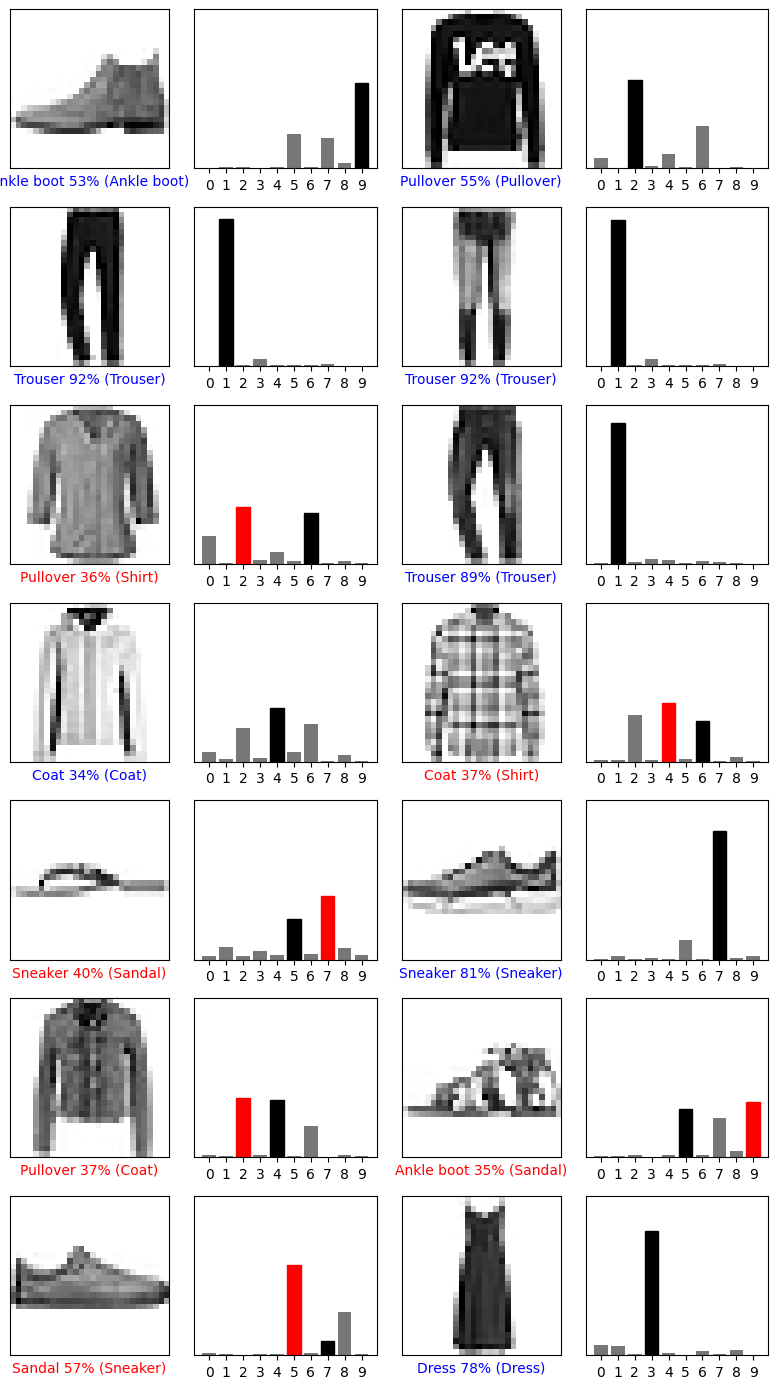

In [18]:
num_rows = 7
num_cols = 2
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  plot_image(i, predictions[i], test_labels, test_images)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plot_value_array(i, predictions[i], test_labels)
plt.tight_layout()
plt.show()

# **Mejorar el modelo**

Podríamos decir que el resultado es el esperado pero se podría mejorar, por ejemplo cambiaremos el optimizador empleado por otro que puede converger mejor el proceso de optimización.

In [19]:
model = keras.Sequential()
model.add(keras.layers.Flatten(input_shape=(28, 28)))
model.add(keras.layers.Dense(10, activation='sigmoid'))
model.add(keras.layers.Dense(10, activation='softmax'))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.fit(train_images, train_labels, epochs=5)

test_loss, test_acc = model.evaluate(test_images, test_labels)

print('Test accuracy:', test_acc)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7076 - loss: 1.0383
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 973us/step - accuracy: 0.8230 - loss: 0.5619
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 968us/step - accuracy: 0.8402 - loss: 0.4710
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 906us/step - accuracy: 0.8497 - loss: 0.4355
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 909us/step - accuracy: 0.8540 - loss: 0.4182
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 944us/step - accuracy: 0.8437 - loss: 0.4492
Test accuracy: 0.8436999917030334
